# HW#2 - Digital Image Processing
2023078032 조윤정

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

IMG_DIR = r'C:\Users\HOME\yunnjj72\CV\HW2\Data'
RESULT_DIR = r'C:\Users\HOME\yunnjj72\CV\HW2\result'

def load_image(filename, grayscale=True):
    path = os.path.join(IMG_DIR, filename)
    pil_img = Image.open(path)
    if grayscale:
        pil_img = pil_img.convert('L')
    return np.array(pil_img)

print('라이브러리 로드 완료!')
print(f'이미지 경로: {IMG_DIR}')
print(f'결과 저장 경로: {RESULT_DIR}')

라이브러리 로드 완료!
이미지 경로: C:\Users\HOME\yunnjj72\CV\HW2\Data
결과 저장 경로: C:\Users\HOME\yunnjj72\CV\HW2\result


---
## HW#2-1 : Power-Law (Gamma) 변환
**내용:** Fig3.9(a) 항공 이미지에 대해 (γ=3.0, 4.0, 5.0) 적용

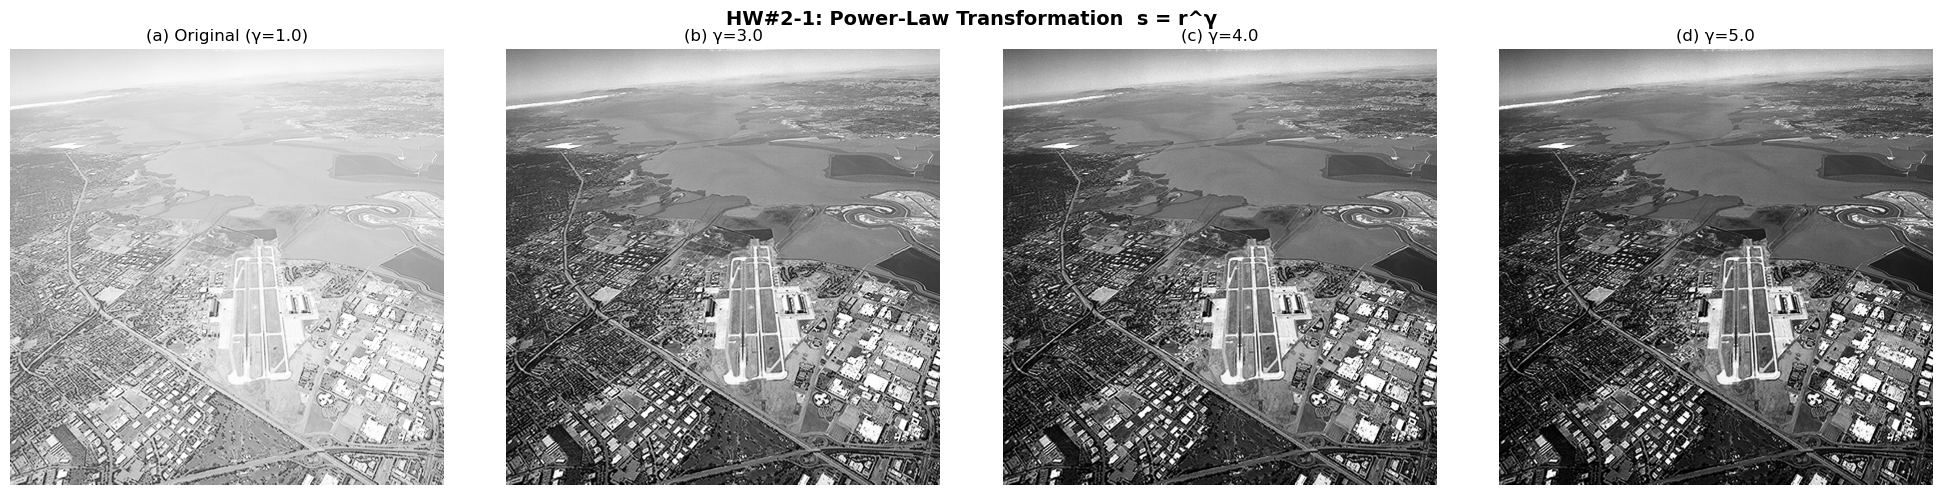

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3199155654.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(result.ravel(), 256, [0, 256], color='steelblue', alpha=0.8)
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3199155654.py:24: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3199155654.py:24: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HOME\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\HOME\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE G

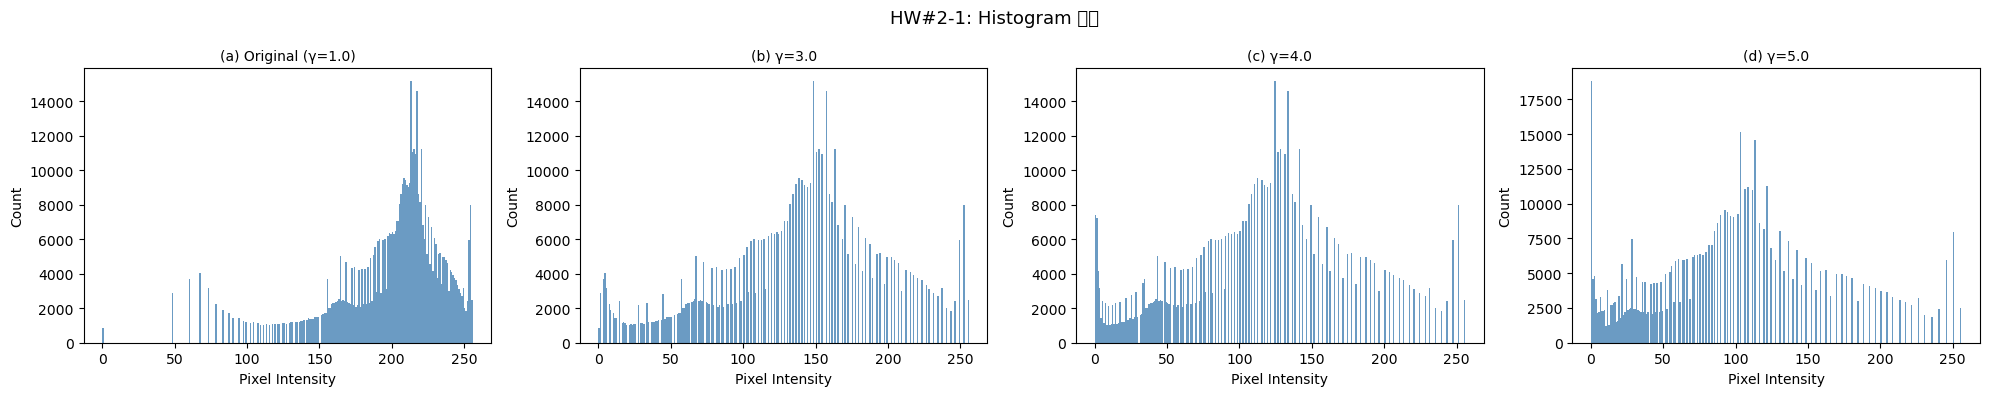

In [4]:
img1 = load_image('Fig0309(a)(washed_out_aerial_image).tif')
img1_norm = img1 / 255.0

gammas = [1.0, 3.0, 4.0, 5.0]
titles = ['(a) Original (γ=1.0)', '(b) γ=3.0', '(c) γ=4.0', '(d) γ=5.0']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('HW#2-1: Power-Law Transformation  s = r^γ', fontsize=14, fontweight='bold')
for ax, gamma, title in zip(axes, gammas, titles):
    result = np.power(img1_norm, gamma)
    ax.imshow(result, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_1_result.png'), dpi=150, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4))
fig2.suptitle('HW#2-1: Histogram 비교', fontsize=13)
for ax, gamma, title in zip(axes2, gammas, titles):
    result = (np.power(img1_norm, gamma) * 255).astype(np.uint8)
    ax.hist(result.ravel(), 256, [0, 256], color='steelblue', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Pixel Intensity'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### HW#2-1 분석
- **γ < 1**: 어두운 영역을 밝게 → 밝은 영역이 압축됨
- **γ > 1**: 밝은 영역을 어둡게 압축 → 전체적으로 어두워지며 대비가 강조됨
- 원본 영상은 히스토그램이 밝은 쪽에 몰려 있어 γ를 높이면 픽셀이 어두운 쪽으로 재분포됨
- γ=3.0일 때 대비가 가장 자연스럽게 개선되며, γ=5.0에서는 너무 어두워져 세부 정보가 손실됨
- **결론**: 밝은 곳이 뭉개진 영상 개선에 γ > 1 변환이 효과적이며, 적절한 γ 값 선택이 중요함

---
## HW#2-2 : Contrast Stretching + Thresholding
**내용:** Fig3.10(a) 화분 이미지에 piecewise-linear 변환 함수 T(r) 적용

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137524.py:42: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137524.py:42: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137524.py:42: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137524.py:42: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137524.py:43: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(RESULT_DIR, 'hw2_2_result.png'), dpi=150, bbox_inches='tight')
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1686137

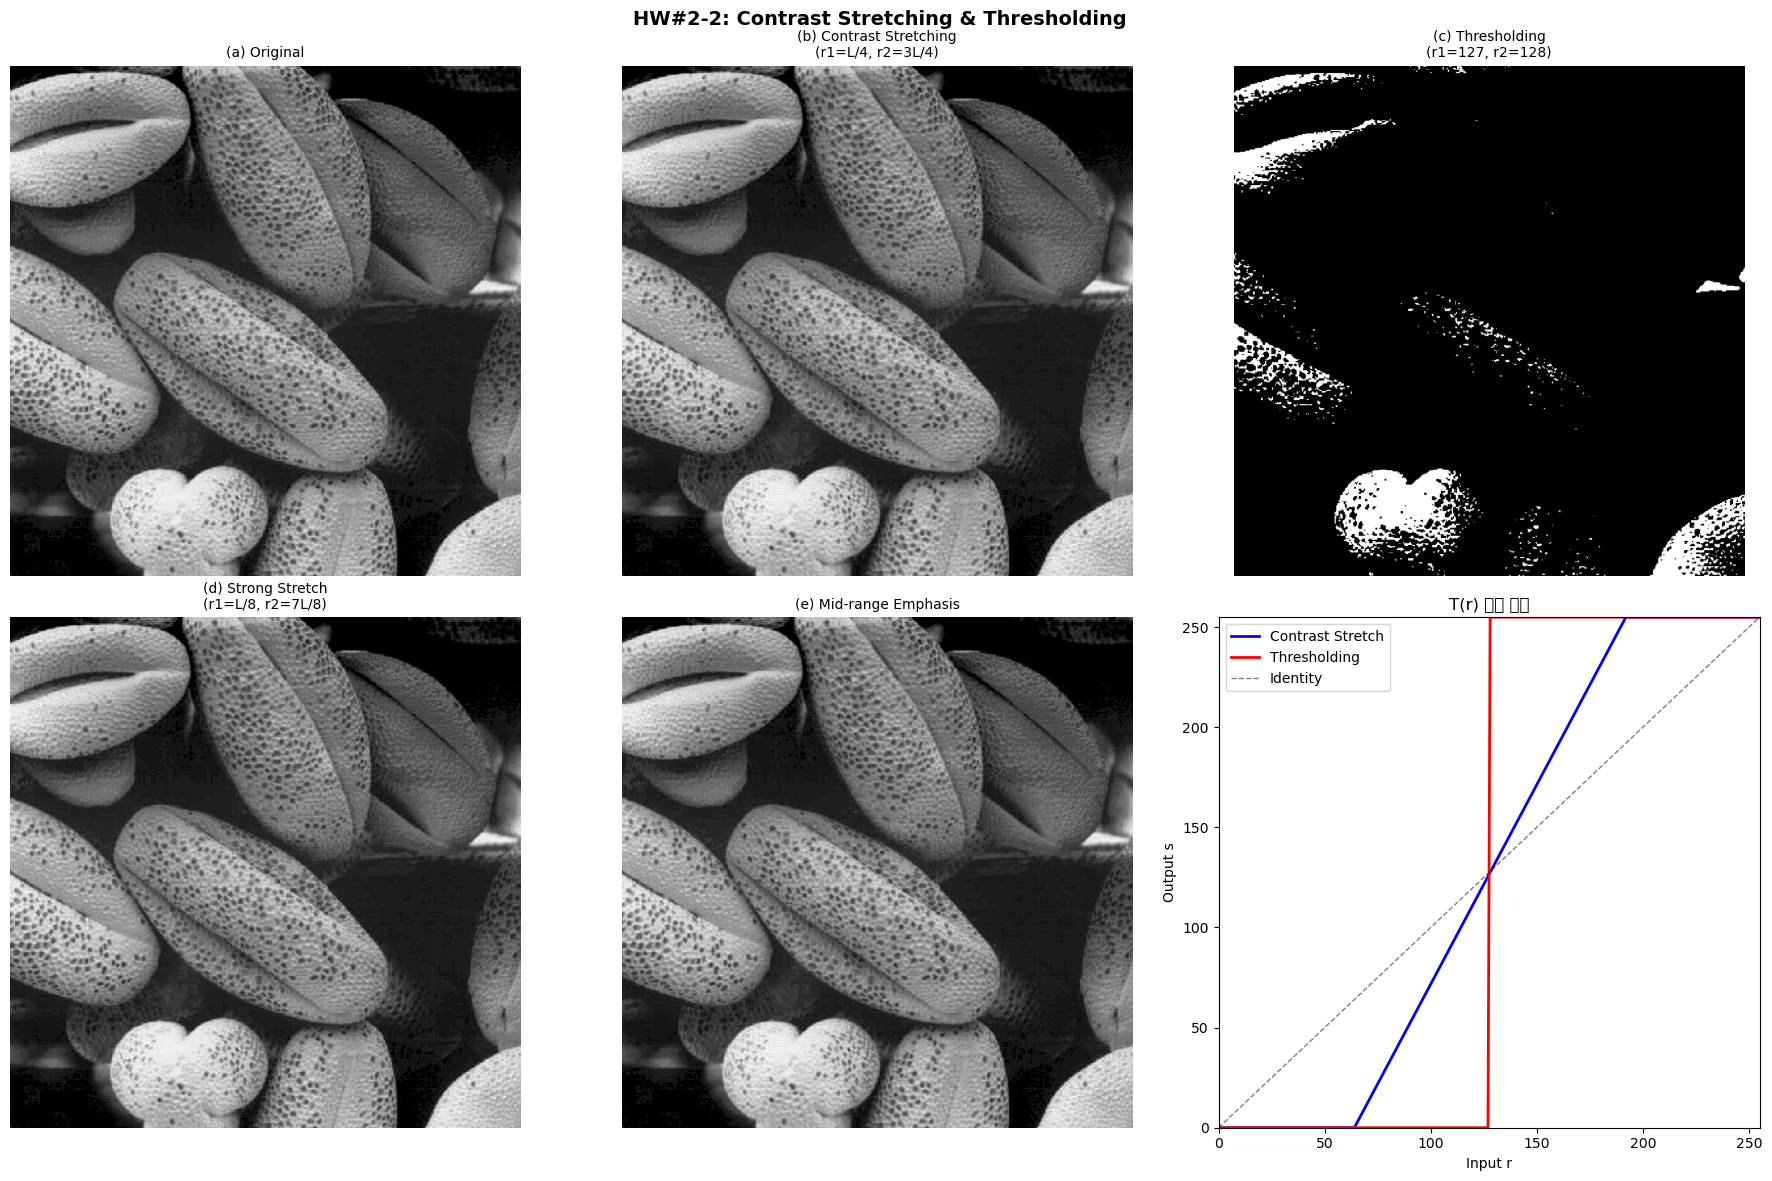

In [5]:
img2 = load_image('Fig0310(b)(washed_out_pollen_image).tif')
L = 256

def contrast_stretch(img, r1, s1, r2, s2):
    lut = np.zeros(256, dtype=np.float32)
    for r in range(256):
        if r <= r1:
            lut[r] = (s1 / r1) * r if r1 > 0 else 0
        elif r <= r2:
            lut[r] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
        else:
            lut[r] = ((255 - s2) / (255 - r2)) * (r - r2) + s2 if r2 < 255 else 255
    return np.clip(lut[img], 0, 255).astype(np.uint8)

stretched   = contrast_stretch(img2, L//4, 0, 3*L//4, L-1)
thresholded = contrast_stretch(img2, 127, 0, 128, 255)
exp1 = contrast_stretch(img2, L//8, 0, 7*L//8, L-1)
exp2 = contrast_stretch(img2, L//3, L//6, 2*L//3, 5*L//6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HW#2-2: Contrast Stretching & Thresholding', fontsize=14, fontweight='bold')
images = [img2, stretched, thresholded, exp1, exp2]
labels = ['(a) Original', '(b) Contrast Stretching\n(r1=L/4, r2=3L/4)',
          '(c) Thresholding\n(r1=127, r2=128)',
          '(d) Strong Stretch\n(r1=L/8, r2=7L/8)',
          '(e) Mid-range Emphasis']
for ax, im, label in zip(axes.flatten()[:5], images, labels):
    ax.imshow(im, cmap='gray'); ax.set_title(label, fontsize=10); ax.axis('off')

ax_g = axes[1, 2]
r = np.arange(256)
def lut_line(r1, s1, r2, s2):
    return np.clip(np.where(r<=r1, (s1/r1)*r if r1>0 else 0,
           np.where(r<=r2, ((s2-s1)/(r2-r1))*(r-r1)+s1,
                    ((255-s2)/(255-r2))*(r-r2)+s2)), 0, 255)
ax_g.plot(r, lut_line(L//4,0,3*L//4,L-1), 'b-', label='Contrast Stretch', linewidth=2)
ax_g.plot(r, lut_line(127,0,128,255), 'r-', label='Thresholding', linewidth=2)
ax_g.plot(r, r, 'k--', label='Identity', linewidth=1, alpha=0.5)
ax_g.set_xlabel('Input r'); ax_g.set_ylabel('Output s')
ax_g.set_title('T(r) 변환 함수'); ax_g.legend()
ax_g.set_xlim(0,255); ax_g.set_ylim(0,255)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_2_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-2 분석
- **Contrast Stretching**: T(r)의 기울기가 1보다 큰 구간의 픽셀 차이가 증폭되어 대비 향상
- **(r1=L/4, r2=3L/4)**: 중간 밝기 구간을 전체 범위로 늘려 대비를 효과적으로 향상
- **Thresholding**: r1≈r2일 때 T(r)이 계단 함수가 되어 이진화 결과와 동일
- **결론**: (r1, s1), (r2, s2) 좌표 선택이 결과를 결정하며, 히스토그램 분석 후 적절한 값 설정이 중요함

---
## HW#2-3 : 다양한 Convolution 마스크 적용

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\3592991529.py:55: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missin

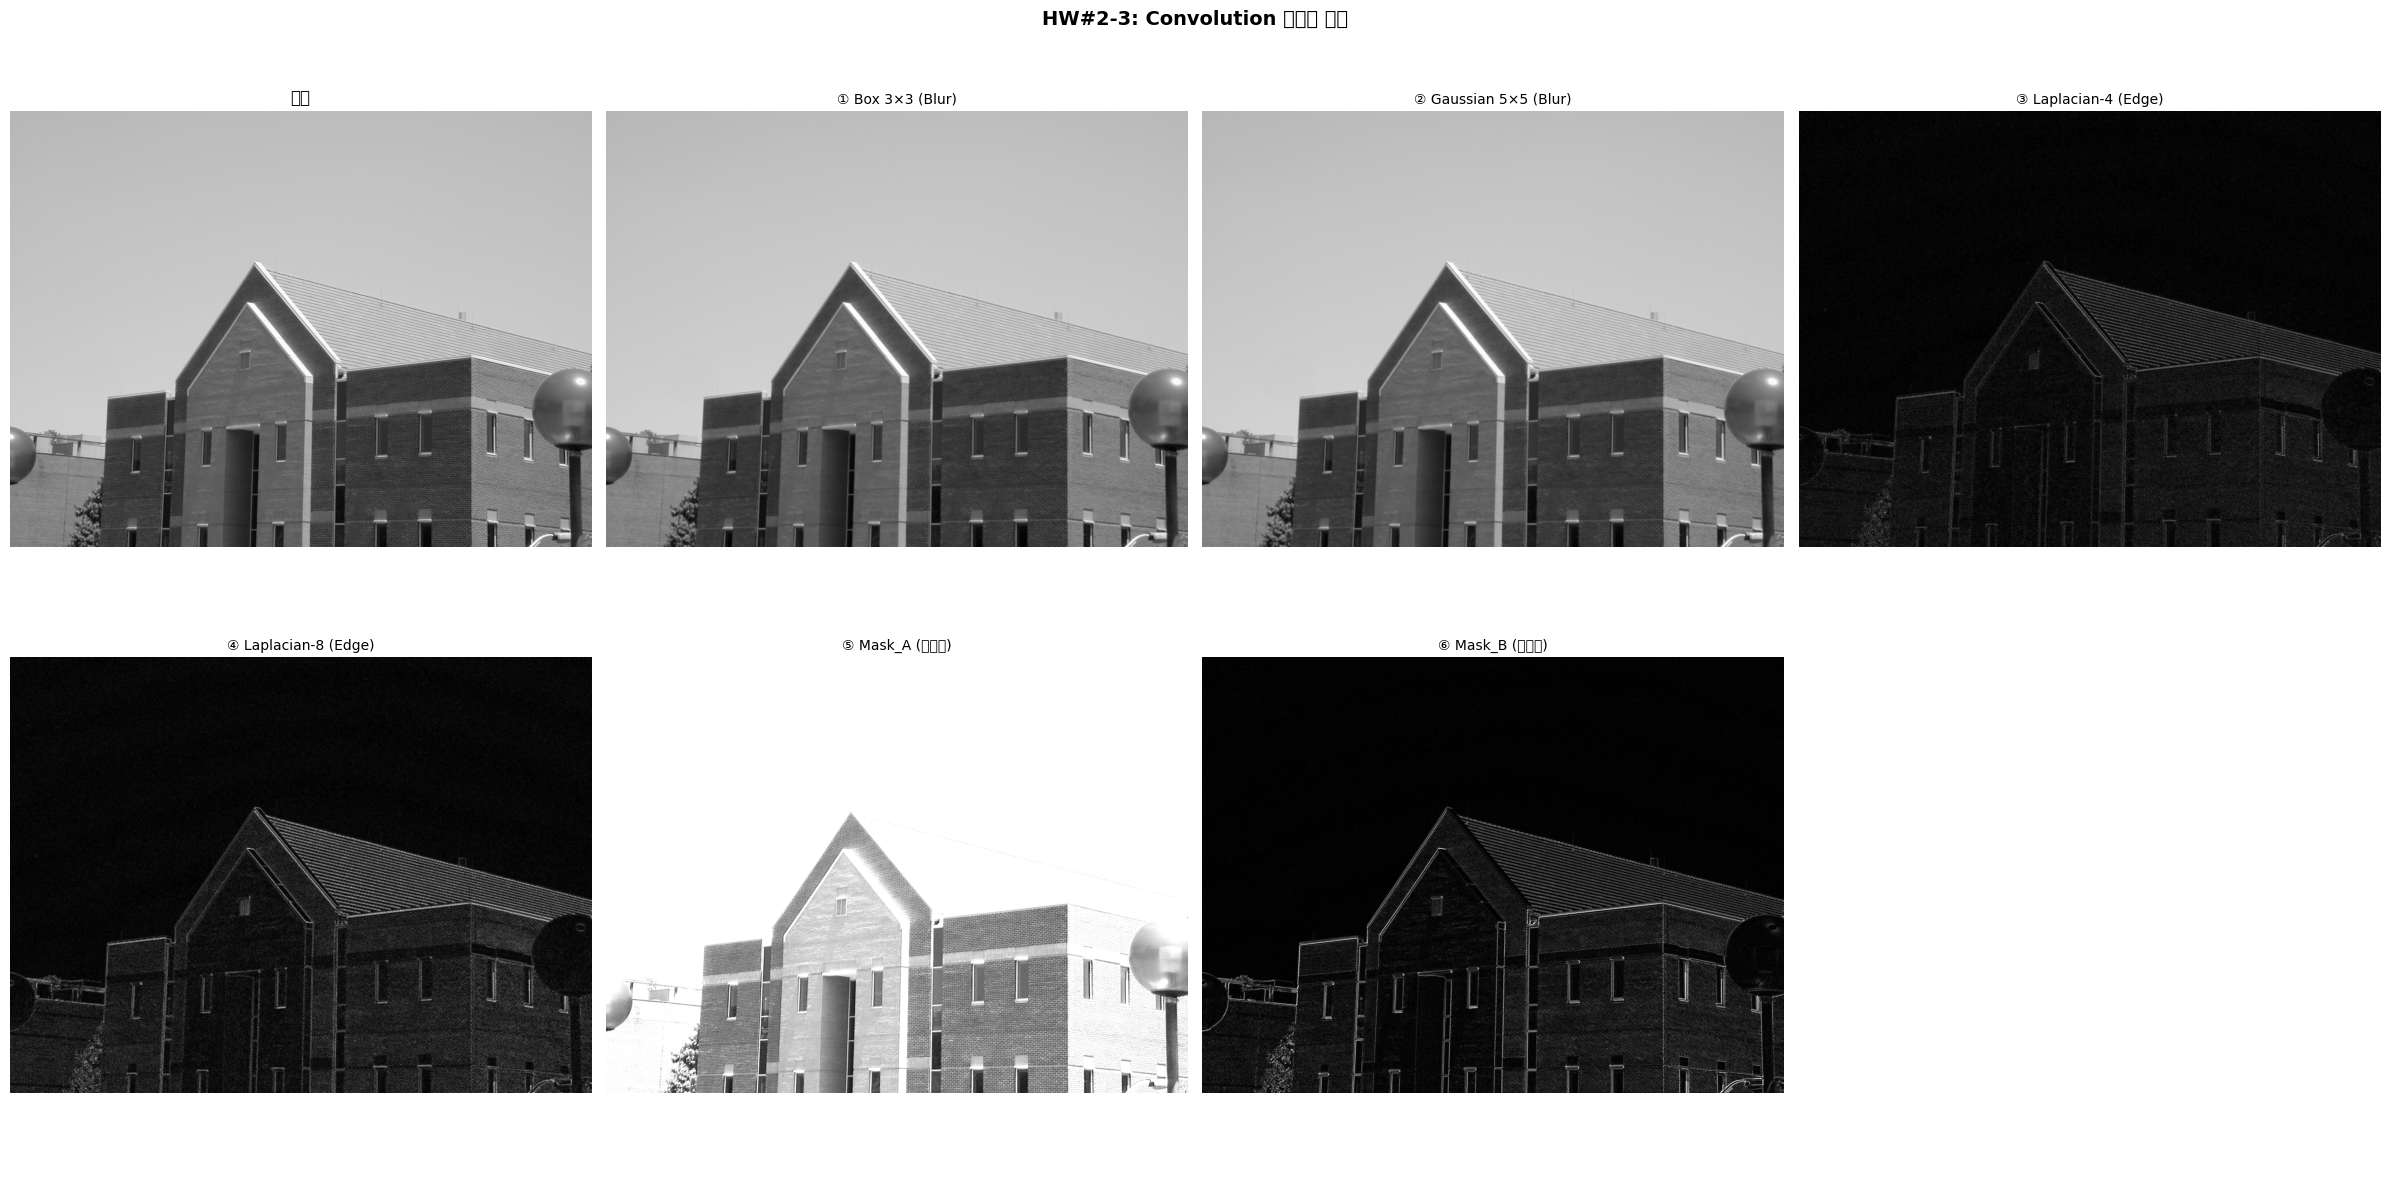

In [6]:
img3 = load_image('school.jpg')

box3 = np.ones((3, 3), np.float32) / 9
gaussian5 = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
], np.float32)

laplacian4 = np.array([[ 0,-1, 0],
                       [-1, 4,-1],
                       [ 0,-1, 0]], np.float32)

laplacian8 = np.array([[-1,-1,-1],
                       [-1, 8,-1],
                       [-1,-1,-1]], np.float32)

mask_a = np.array([[-1, 0, 0],
                   [-1,-1, 0],
                   [ 0, 0, 1]], np.float32)

mask_b = np.array([[-1,-1, 0],
                   [-1, 0, 1],
                   [ 0, 1, 1]], np.float32)

masks = [box3, gaussian5, laplacian4, laplacian8, mask_a, mask_b]
titles = ['① Box 3×3 (Blur)', '② Gaussian 5×5 (Blur)',
          '③ Laplacian-4 (Edge)', '④ Laplacian-8 (Edge)',
          '⑤ Mask_A (방향성)', '⑥ Mask_B (방향성)']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('HW#2-3: Convolution 마스크 비교', fontsize=14, fontweight='bold')

axes[0, 0].imshow(img3, cmap='gray')
axes[0, 0].set_title('원본')
axes[0, 0].axis('off')

for i, (mask, title) in enumerate(zip(masks, titles)):
    row, col = divmod(i + 1, 4)
    result = cv2.filter2D(img3.astype(np.float32), cv2.CV_32F, mask)

    # blur 계열은 그대로, edge 계열은 절댓값 시각화
    if i < 2:
        show = np.clip(result, 0, 255).astype(np.uint8)
    else:
        show = np.clip(np.abs(result), 0, 255).astype(np.uint8)

    axes[row, col].imshow(show, cmap='gray')
    axes[row, col].set_title(title, fontsize=10)
    axes[row, col].axis('off')

axes[1, 3].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_3_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-3 분석
- **① Box 3×3**: 주변 화소의 평균을 사용하므로 영상이 전체적으로 부드러워지고 작은 잡음이 감소하지만, 경계가 흐려짐
- **② Gaussian 5×5**: 중심에 더 큰 가중치를 주는 smoothing 필터로, Box 필터보다 자연스럽게 블러링되며 구조를 비교적 잘 유지
- **③ Laplacian-4**: 밝기 변화가 큰 경계 부분이 강조되며, 방향성 없이 edge를 검출
- **③ Laplacian-8**: Laplacian-4보다 더 강하게 edge를 강조하며, 더 많은 세부 변화에 반응
- **④ Mask_A**: 특정 방향의 edge에 더 민감하게 반응하여 방향성 있는 경계가 강조
- **④ Mask_A**: Mask_A와 다른 방향의 edge를 강조하며, 방향에 따라 응답이 달라짐
- **결론**: 평균/가우시안 마스크는 smoothing에 적합하고, Laplacian 및 방향성 마스크는 edge와 밝기 변화 검출에 효과적

---
## HW#2-4 : 대각선 방향 Edge 검출 (Sobel 변형)

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 50659 (\N{HANGUL SYLLABLE ES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\381151163.py:38: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s

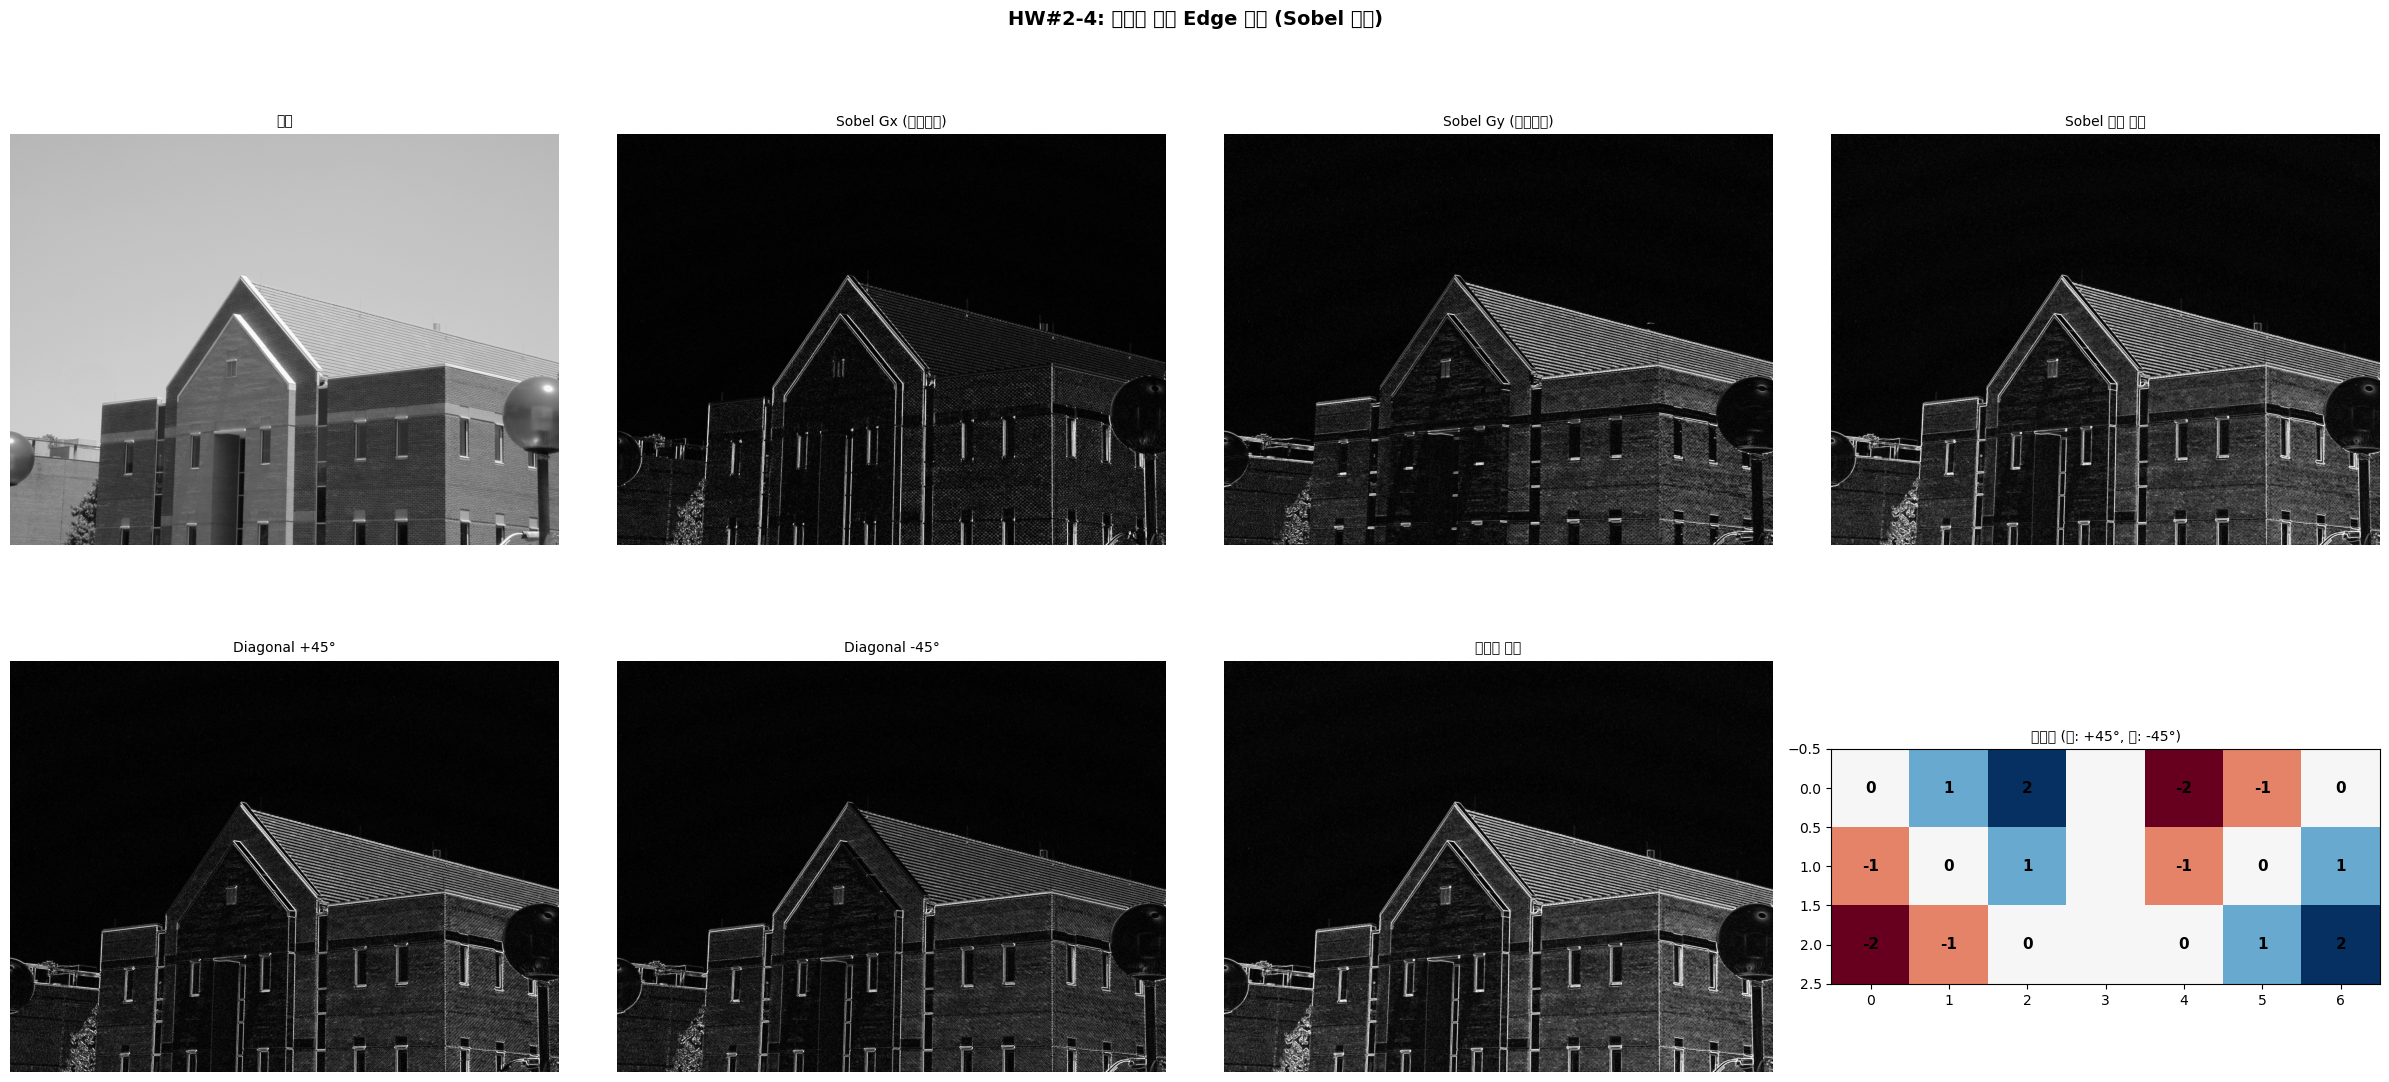

In [7]:
img4 = load_image('school.jpg')

Gx = cv2.Sobel(img4, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img4, cv2.CV_64F, 0, 1, ksize=3)
G_std = np.sqrt(Gx**2 + Gy**2)

sobel_p45 = np.array([[ 0,  1,  2],
                       [-1,  0,  1],
                       [-2, -1,  0]], dtype=np.float32)
sobel_m45 = np.array([[-2, -1,  0],
                       [-1,  0,  1],
                       [ 0,  1,  2]], dtype=np.float32)
G_p45  = cv2.filter2D(img4.astype(np.float64), -1, sobel_p45)
G_m45  = cv2.filter2D(img4.astype(np.float64), -1, sobel_m45)
G_diag = np.sqrt(G_p45**2 + G_m45**2)

def norm(img):
    return np.clip(np.abs(img), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('HW#2-4: 대각선 방향 Edge 검출 (Sobel 변형)', fontsize=14, fontweight='bold')
imgs_show = [img4, norm(Gx), norm(Gy), norm(G_std),
             norm(G_p45), norm(G_m45), norm(G_diag)]
labels = ['원본', 'Sobel Gx (수직엣지)', 'Sobel Gy (수평엣지)', 'Sobel 표준 합성',
          'Diagonal +45°', 'Diagonal -45°', '대각선 합성']
for ax, im, lb in zip(axes.flatten()[:7], imgs_show, labels):
    ax.imshow(im, cmap='gray'); ax.set_title(lb, fontsize=10); ax.axis('off')

ax_m = axes[1, 3]
mask_vis = np.zeros((3, 7), dtype=np.float32)
mask_vis[:, :3] = sobel_p45; mask_vis[:, 4:] = sobel_m45
ax_m.imshow(mask_vis, cmap='RdBu', vmin=-2, vmax=2)
ax_m.set_title('마스크 (좌: +45°, 우: -45°)', fontsize=10)
for i in range(3):
    for j in range(3):
        ax_m.text(j,   i, int(sobel_p45[i,j]), ha='center', va='center', fontsize=11, fontweight='bold')
        ax_m.text(j+4, i, int(sobel_m45[i,j]), ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_4_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-4 분석
- **+45° 마스크**: 표준 Sobel을 45° 회전. ↗ 방향(우상-좌하) 경계에 강하게 반응
- **-45° 마스크**: 표준 Sobel을 -45° 회전. ↘ 방향 경계에 강하게 반응
- 건물의 경사 지붕선이 두 대각선 마스크에서 명확하게 검출됨
- **결론**: 방향별 마스크 조합으로 원하는 엣지 방향 선택 검출 가능

---
## HW#2-5 : 지문 영상 개선

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2651400012.py:31: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing f

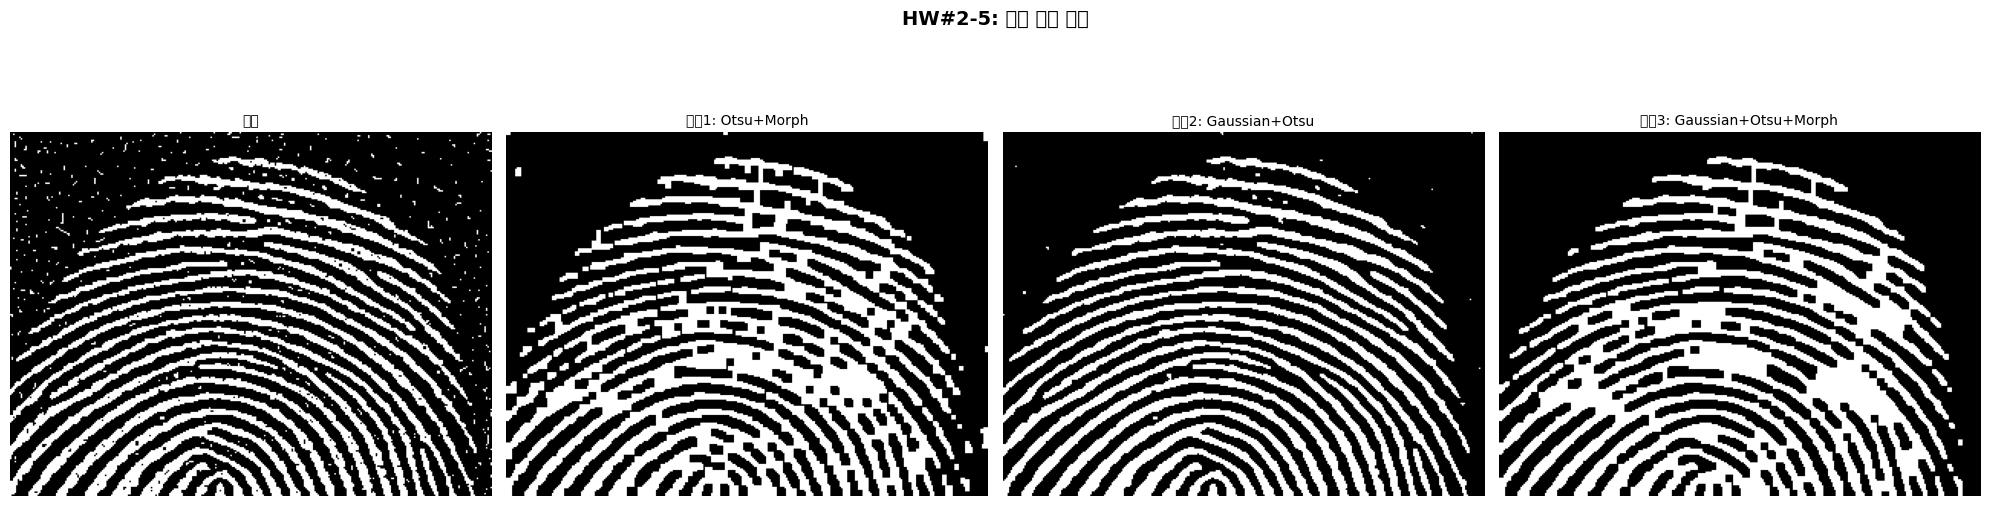

In [8]:
img5 = load_image('finger.jpg')
kernel3 = np.ones((3, 3), np.uint8)

# 방법1: Otsu + Morphology
_, otsu = cv2.threshold(img5, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
method1 = cv2.morphologyEx(otsu,    cv2.MORPH_CLOSE, kernel3, iterations=2)
method1 = cv2.morphologyEx(method1, cv2.MORPH_OPEN,  kernel3, iterations=1)

# 방법2: Gaussian + Otsu
blurred = cv2.GaussianBlur(img5, (5, 5), 0)
_, method2 = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 방법3: Gaussian + Otsu + Morphology
blurred2 = cv2.GaussianBlur(img5, (5, 5), 0)
_, method3 = cv2.threshold(blurred2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
method3 = cv2.morphologyEx(method3, cv2.MORPH_CLOSE, kernel3, iterations=2)
method3 = cv2.morphologyEx(method3, cv2.MORPH_OPEN,  kernel3, iterations=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('HW#2-5: 지문 영상 개선', fontsize=14, fontweight='bold')

for ax, im, title in zip(
    axes,
    [img5, method1, method2, method3],
    ['원본', '방법1: Otsu+Morph', '방법2: Gaussian+Otsu', '방법3: Gaussian+Otsu+Morph']
):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_5_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-5 분석
- **원본**: salt-and-pepper 노이즈가 많아 지문선 인식이 어려움
- **방법1 (Otsu + Morph)**: 전역 임계값 → 조명 불균일에 취약. Close로 선 연결, Open으로 점 노이즈 제거
- **방법2 (Gaussian + Otsu)**: Gaussian smoothing으로 잡음을 완화한 뒤 Otsu로 이진화
- **방법3 (Gaussian + Otsu + Morph)**: Gaussian smooting 후 Otsu 적용, Close로 선 열결, Open으로 점 노이즈 제거
- **결론**: Gaussian + Otsu + Morph 조합이 가장 효과적

---
## HW#2-6 : 선분 제거 (Morphological Opening)

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1767217865.py:24: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missin

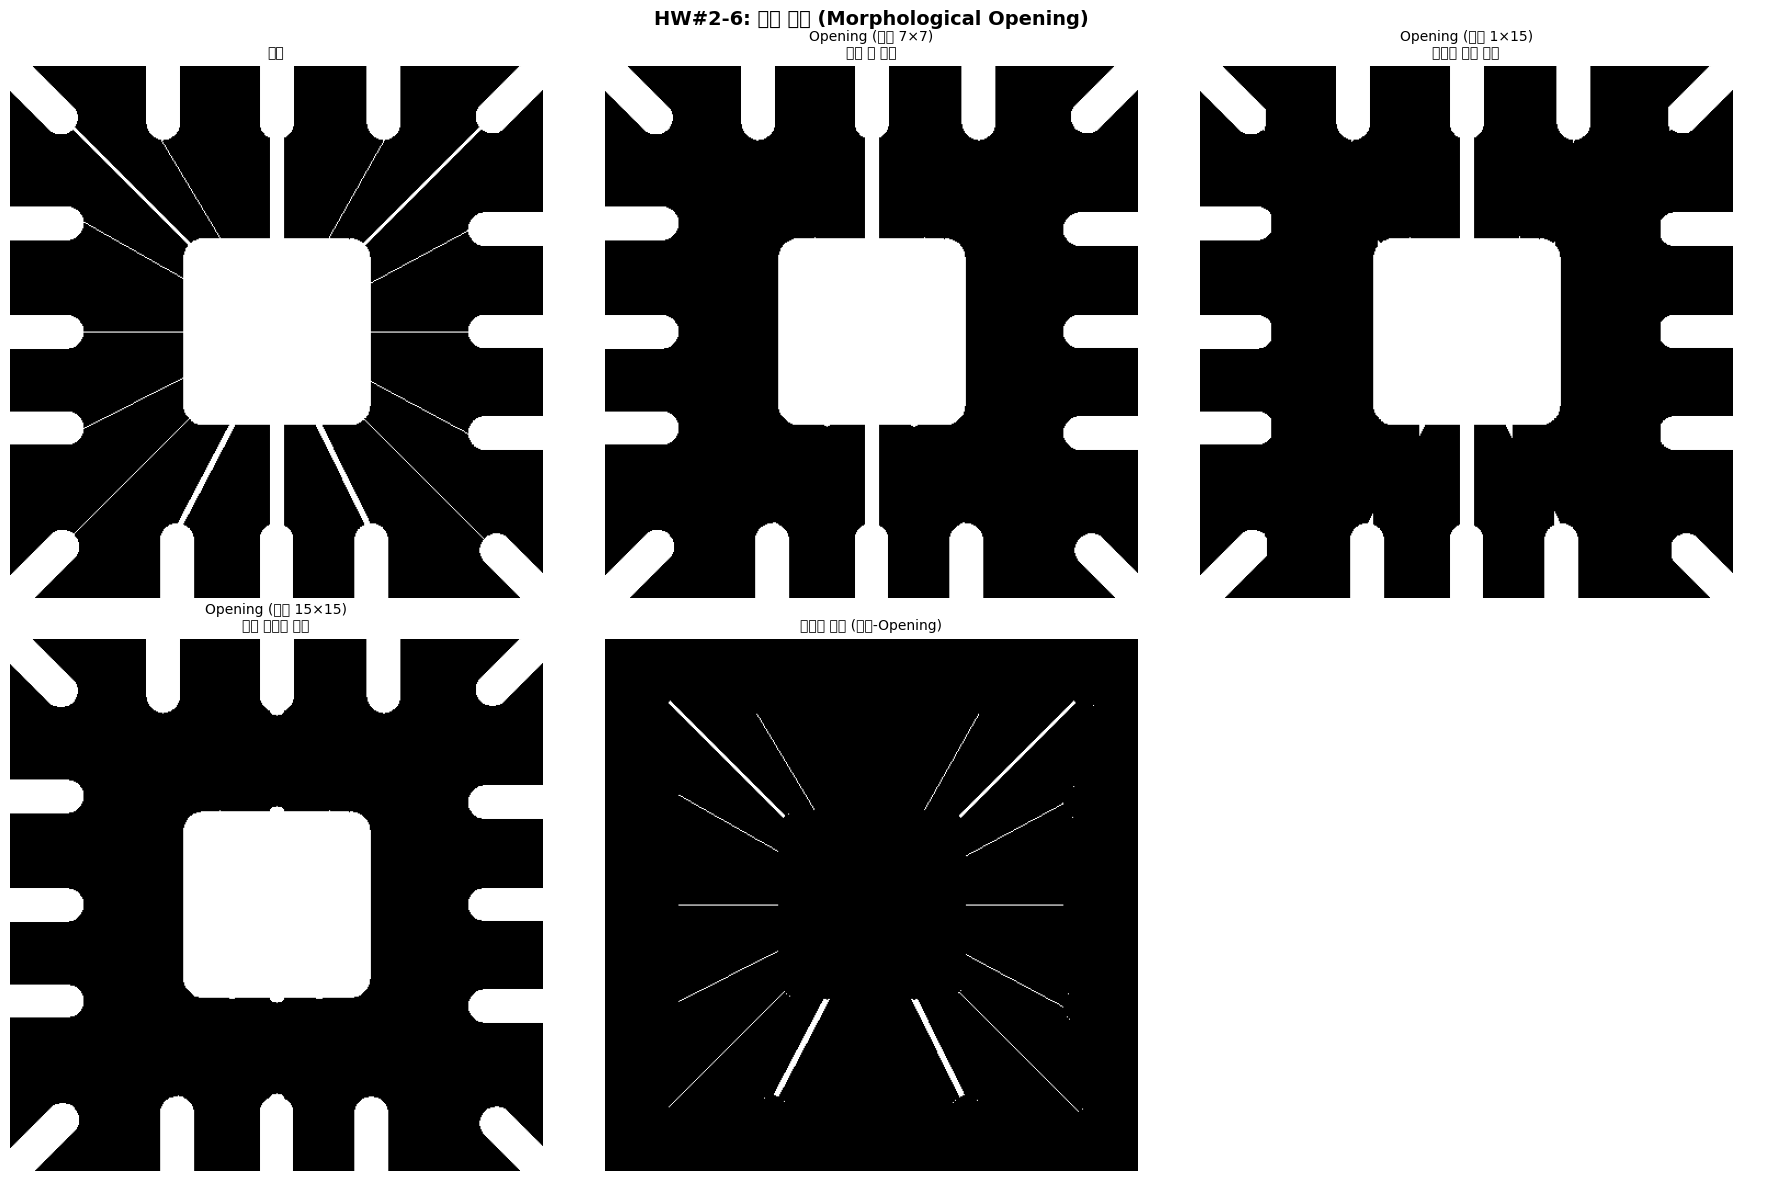

In [9]:
img6 = load_image('Fig0905(a)(wirebond-mask).tif')

se_circle = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
removed_all  = cv2.morphologyEx(img6, cv2.MORPH_OPEN, se_circle)

se_horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 15))
removed_vert = cv2.morphologyEx(img6, cv2.MORPH_OPEN, se_horiz)

se_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
removed_large = cv2.morphologyEx(img6, cv2.MORPH_OPEN, se_large)

wires_only = cv2.subtract(img6, removed_all)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HW#2-6: 선분 제거 (Morphological Opening)', fontsize=14, fontweight='bold')
for ax, im, title in zip(axes.flatten(),
    [img6, removed_all, removed_vert, removed_large, wires_only],
    ['원본', 'Opening (원형 7×7)\n가는 선 제거',
     'Opening (세로 1×15)\n수직선 선택 제거',
     'Opening (원형 15×15)\n굵은 선까지 제거',
     '제거된 선만 (원본-Opening)']):
    ax.imshow(im, cmap='gray'); ax.set_title(title, fontsize=10); ax.axis('off')
axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_6_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-6 분석
- **원리**: Morphological Opening(침식→팽창)은 SE보다 작은 구조를 제거
- **원형 SE (7×7)**: 모든 방향 가는 선 제거, 패드(넓은 영역)는 보존
- **세로 SE (1×15)**: 수직 방향 선만 선택적으로 제거 가능
- **큰 SE (15×15)**: 더 두꺼운 구조까지 제거되어 패드 형태 변형 가능
- **결론**: SE 크기와 형태가 제거할 선의 종류를 결정. 선의 폭보다 크고 패드보다 작은 SE 선택이 핵심

---
## HW#2-7 : Edge 검출 알고리즘 비교

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\1823108832.py:29: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from f

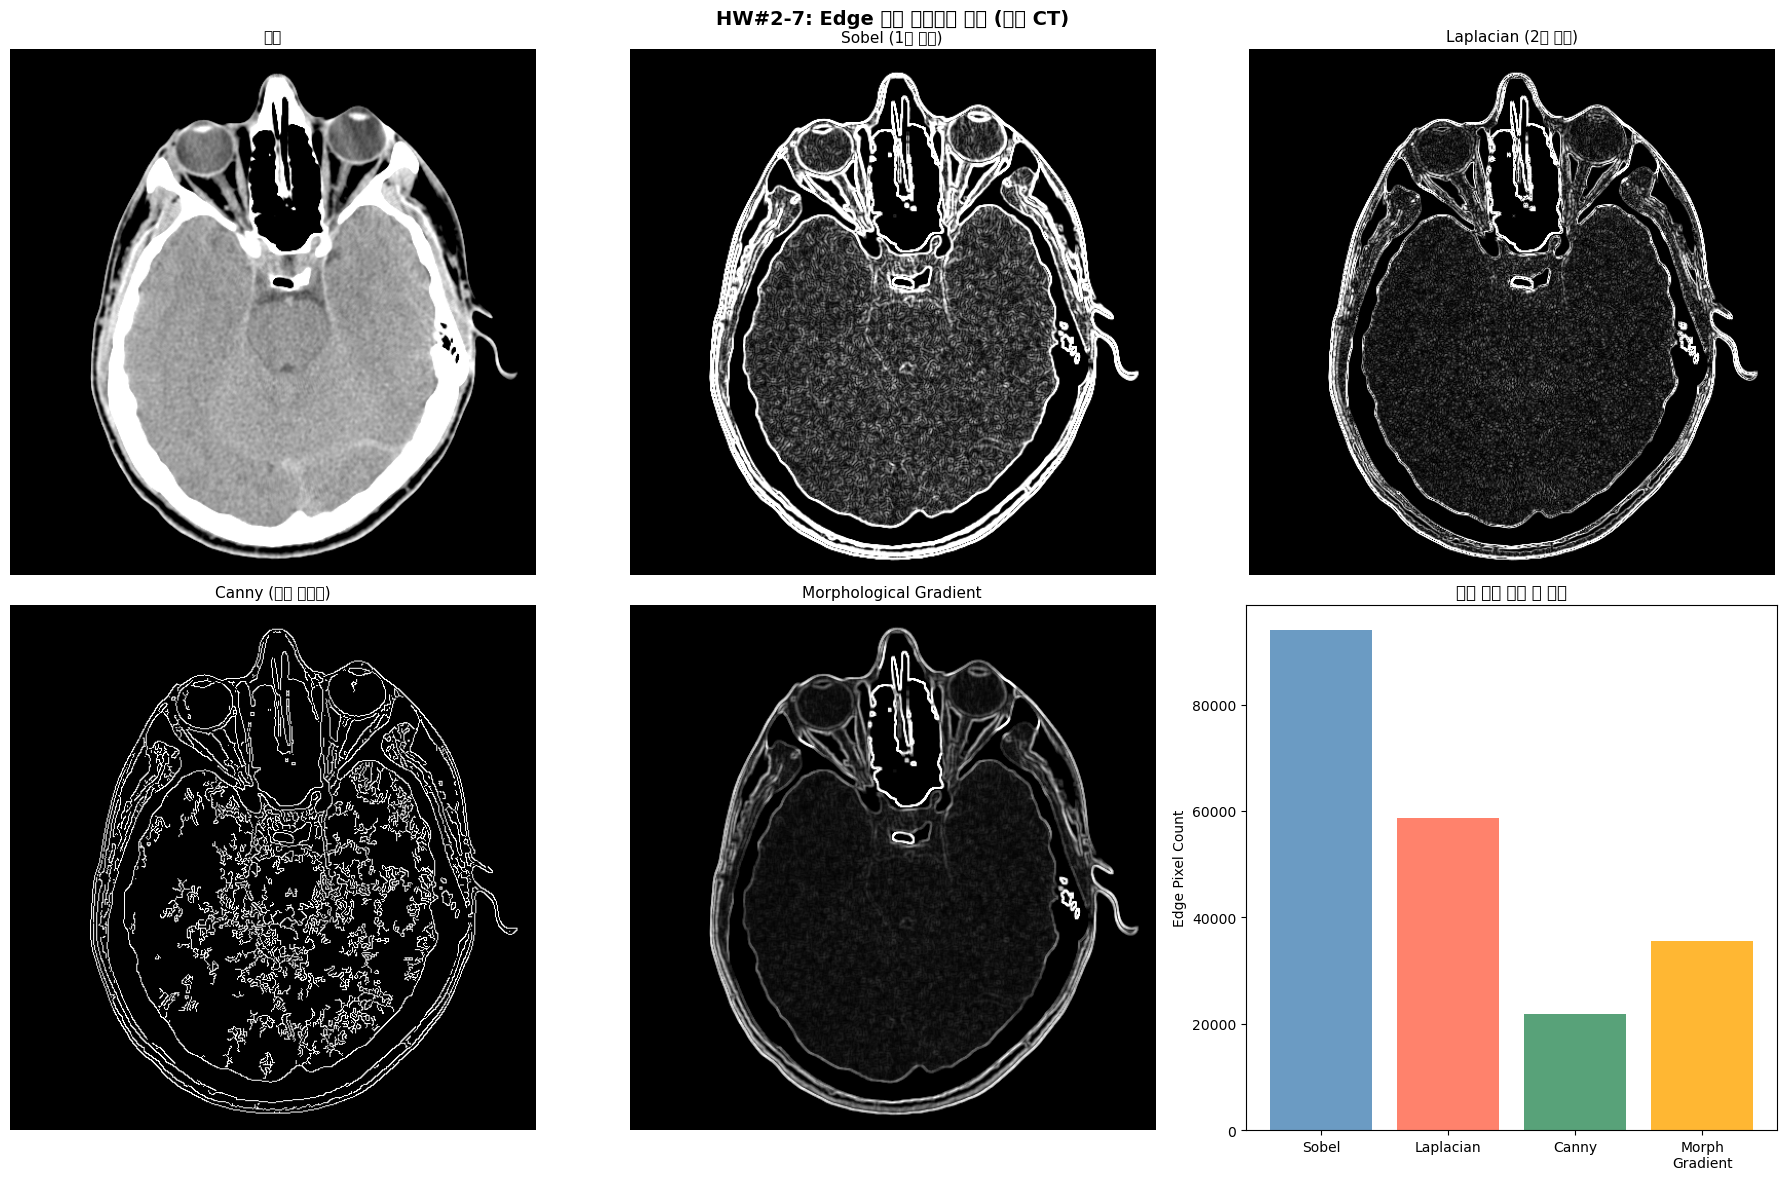

In [10]:
img7 = load_image('Fig0939(a)(headCT-Vandy).tif')

gx = cv2.Sobel(img7, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img7, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.clip(np.abs(gx) + np.abs(gy), 0, 255).astype(np.uint8)

lap = cv2.Laplacian(img7, cv2.CV_64F, ksize=3)
laplacian = np.clip(np.abs(lap), 0, 255).astype(np.uint8)

canny = cv2.Canny(img7, threshold1=50, threshold2=150)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morph_grad = cv2.morphologyEx(img7, cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HW#2-7: Edge 검출 알고리즘 비교 (두부 CT)', fontsize=14, fontweight='bold')
for ax, im, title in zip(axes.flatten(),
    [img7, sobel, laplacian, canny, morph_grad],
    ['원본', 'Sobel (1차 미분)', 'Laplacian (2차 미분)',
     'Canny (이중 임계값)', 'Morphological Gradient']):
    ax.imshow(im, cmap='gray'); ax.set_title(title, fontsize=11); ax.axis('off')

ax_bar = axes[1, 2]
edge_counts = [np.sum(sobel>30), np.sum(laplacian>30),
               np.sum(canny>0),  np.sum(morph_grad>30)]
ax_bar.bar(['Sobel','Laplacian','Canny','Morph\nGradient'],
           edge_counts, color=['steelblue','tomato','seagreen','orange'], alpha=0.8)
ax_bar.set_title('검출 엣지 픽셀 수 비교'); ax_bar.set_ylabel('Edge Pixel Count')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_7_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-7 분석
| 방법 | 원리 | 장점 | 단점 |
|------|------|------|------|
| **Sobel** | 1차 미분 | 방향성 정보 제공 | 노이즈에 민감, 엣지 두꺼움 |
| **Laplacian** | 2차 미분 | 엣지 위치 정밀 | 노이즈 증폭, 이중 엣지 |
| **Canny** | 이중 임계값+NMS | 가장 깔끔한 결과 | 파라미터 튜닝 필요 |
| **Morph Gradient** | 팽창-침식 | 이진 영상에도 적용 가능 | 엣지가 두꺼움 |

- **결론**: CT 영상처럼 경계가 명확한 경우 Canny가 가장 효과적. 응용 목적에 따라 선택

---
## HW#2-8 : 노이즈 제거 비교

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\2569608111.py:24: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing fro

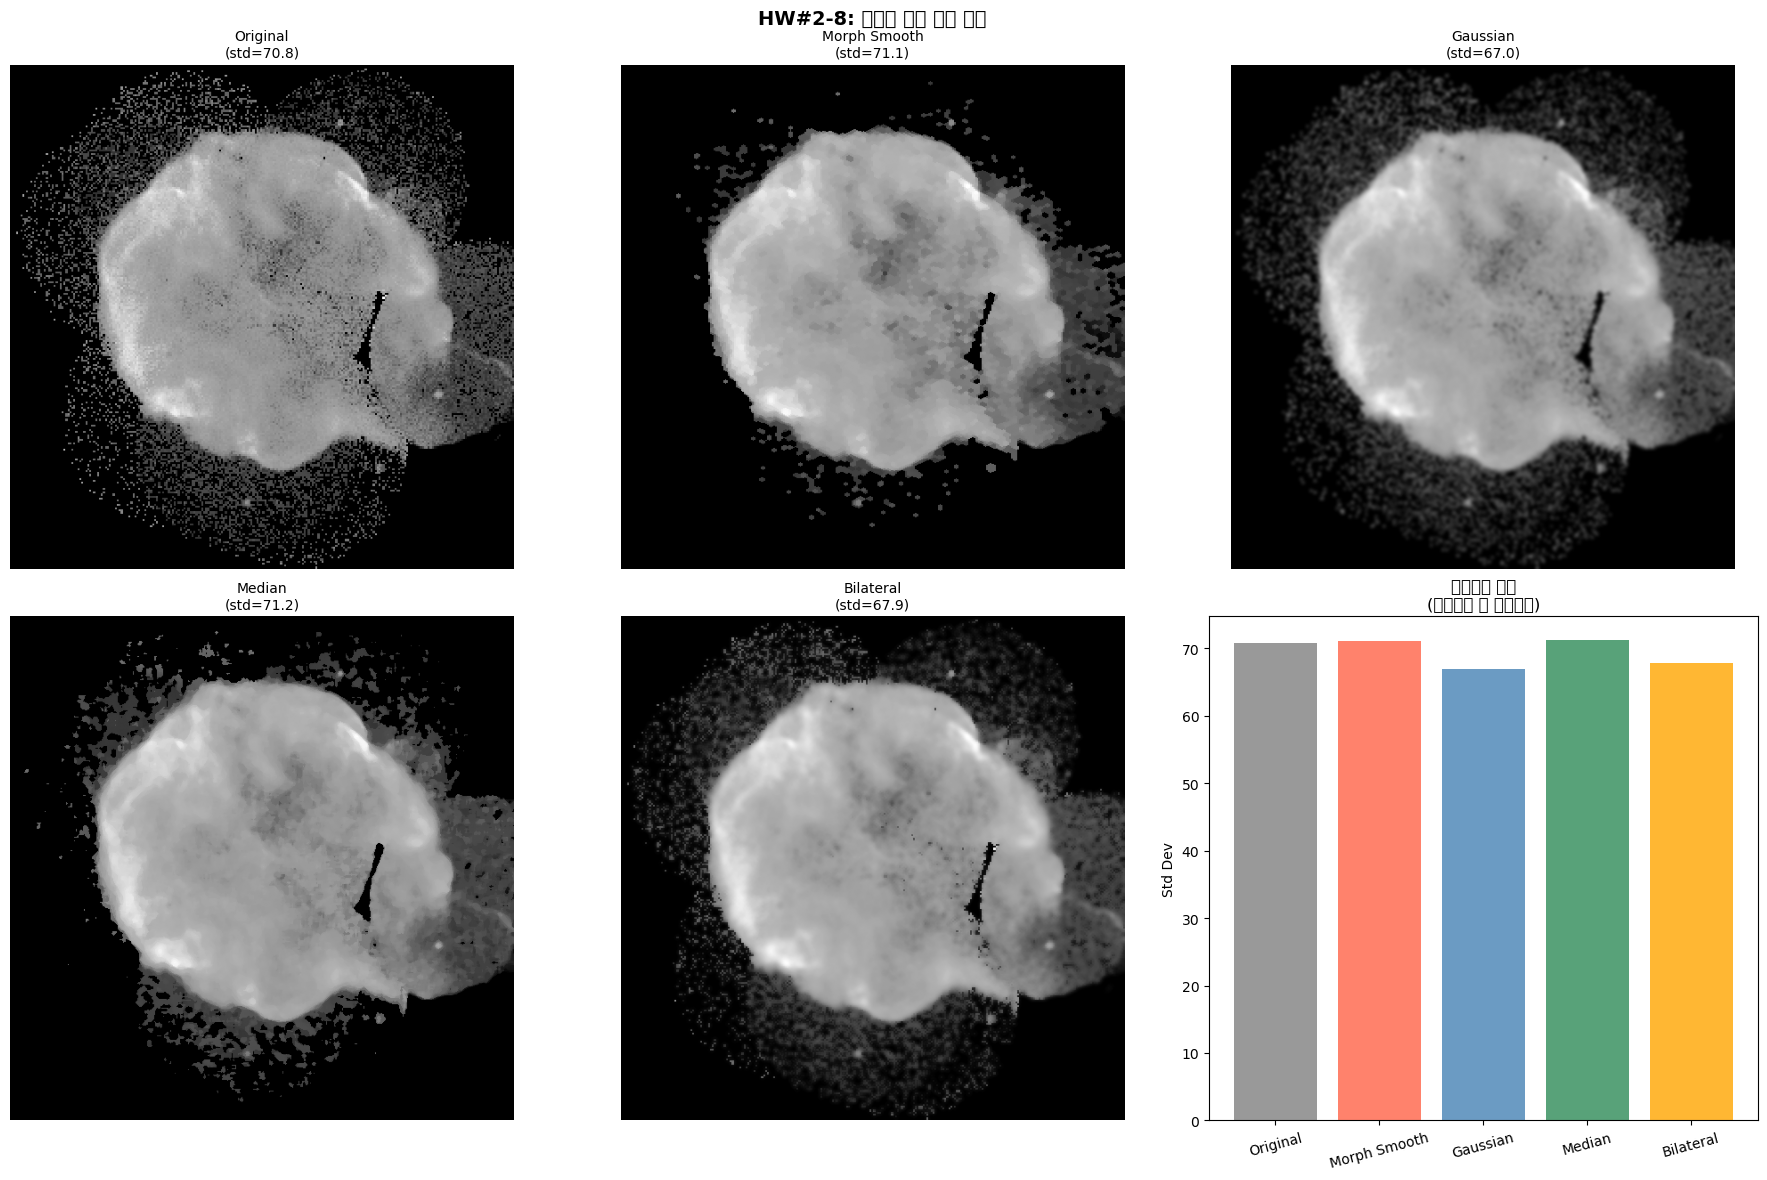

In [11]:
img8 = load_image('Fig0938(a)(cygnusloop_Xray_original).tif')
kernel_e = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

morph_open   = cv2.morphologyEx(img8, cv2.MORPH_OPEN,  kernel_e)
morph_smooth = cv2.morphologyEx(morph_open, cv2.MORPH_CLOSE, kernel_e)
gauss_smooth  = cv2.GaussianBlur(img8, (9, 9), 2)
median_smooth = cv2.medianBlur(img8, 7)
bilateral     = cv2.bilateralFilter(img8, 9, 75, 75)

results_list = [img8, morph_smooth, gauss_smooth, median_smooth, bilateral]
names = ['Original', 'Morph Smooth', 'Gaussian', 'Median', 'Bilateral']
stds  = [np.std(r) for r in results_list]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HW#2-8: 노이즈 제거 방법 비교', fontsize=14, fontweight='bold')
for ax, im, name, std in zip(axes.flatten()[:5], results_list, names, stds):
    ax.imshow(im, cmap='gray')
    ax.set_title(f'{name}\n(std={std:.1f})', fontsize=10); ax.axis('off')

ax_bar = axes[1, 2]
ax_bar.bar(names, stds, color=['gray','tomato','steelblue','seagreen','orange'], alpha=0.8)
ax_bar.set_title('표준편차 비교\n(낮을수록 더 매끄러움)')
ax_bar.set_ylabel('Std Dev'); ax_bar.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_8_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-8 분석
- **Morphological Smoothing (Open→Close)**: Opening으로 밝은 점, Closing으로 어두운 점 노이즈 제거
- **Gaussian**: 균일한 블러 → 노이즈 감소하지만 엣지도 흐려짐
- **Median**: salt-and-pepper 노이즈에 가장 효과적, 엣지 보존 우수
- **Bilateral**: 엣지 보존하면서 균일 영역만 스무딩
- **결론**: X-ray 점 노이즈에는 Median 또는 Morphological Smoothing이 Gaussian보다 효과적

---
## HW#2-9 : 이진화 2가지 방법 비교

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\938404707.py:27: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(im.ravel(), 256, [0, 256], color='steelblue', alpha=0.8)
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\938404707.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\938404707.py:38: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\938404707.py:38: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\938404707.py:38: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Us

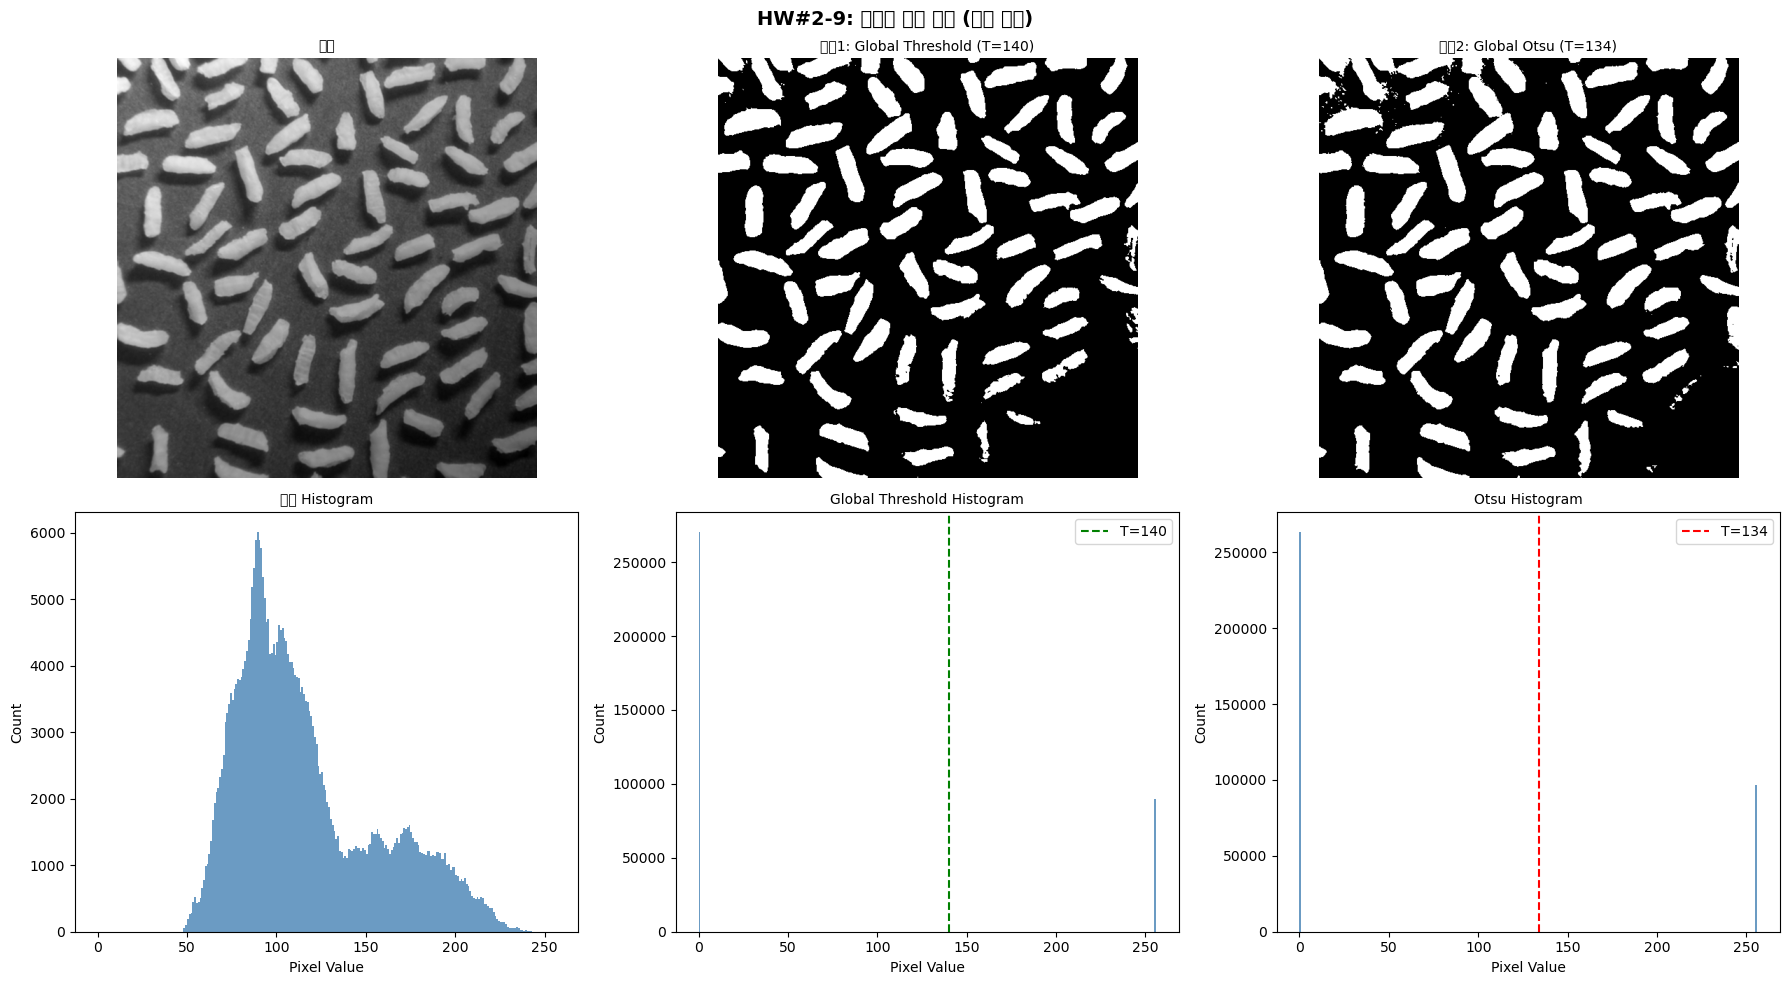

In [12]:
img9 = load_image('Fig0940(a)(rice_image_with_intensity_gradient).tif')

# 방법1: Global Threshold
th_val, global_th = cv2.threshold(img9, 140, 255, cv2.THRESH_BINARY)

# 방법2: Global Otsu
otsu_val, global_otsu = cv2.threshold(img9, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HW#2-9: 이진화 방법 비교 (쌀알 영상)', fontsize=14, fontweight='bold')

for ax, im, title in zip(
    axes[0],
    [img9, global_th, global_otsu],
    ['원본', f'방법1: Global Threshold (T={th_val:.0f})',
     f'방법2: Global Otsu (T={otsu_val:.0f})']
):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

for ax, im, title in zip(
    axes[1],
    [img9, global_th, global_otsu],
    ['원본 Histogram', 'Global Threshold Histogram', 'Otsu Histogram']
):
    ax.hist(im.ravel(), 256, [0, 256], color='steelblue', alpha=0.8)
    if 'Global Threshold' in title:
        ax.axvline(x=th_val, color='green', linestyle='--', label=f'T={th_val:.0f}')
        ax.legend()
    if 'Otsu' in title:
        ax.axvline(x=otsu_val, color='red', linestyle='--', label=f'T={otsu_val:.0f}')
        ax.legend()
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_9_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-9 분석
- **영상 특성**: 쌀알 영상은 조명 그라데이션(intensity gradient) 존재
- **방법1 - Global Threshold**: 단일 임계값 → 밝은 쪽은 잘 분리되지만 어두운 쪽 쌀알이 배경과 합쳐짐
- **방법2 - Global Otsu**: 히스토그램 기반으로 임계값 자동 결정 -> 수동 threshold보다 전체 분리가 더 안정적
- Otsu는 영상 전체 밝기 분포를 반영하여 threshold를 결정함
- **결론**: 조명 불균일 영상에는 Global Threshold보다 Otsu가 더 적절함

---
## HW#2-10 : Morphology를 이용한 영역 분할

C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HOME\AppData\Local\Temp\ipykernel_178980\443918898.py:39: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font

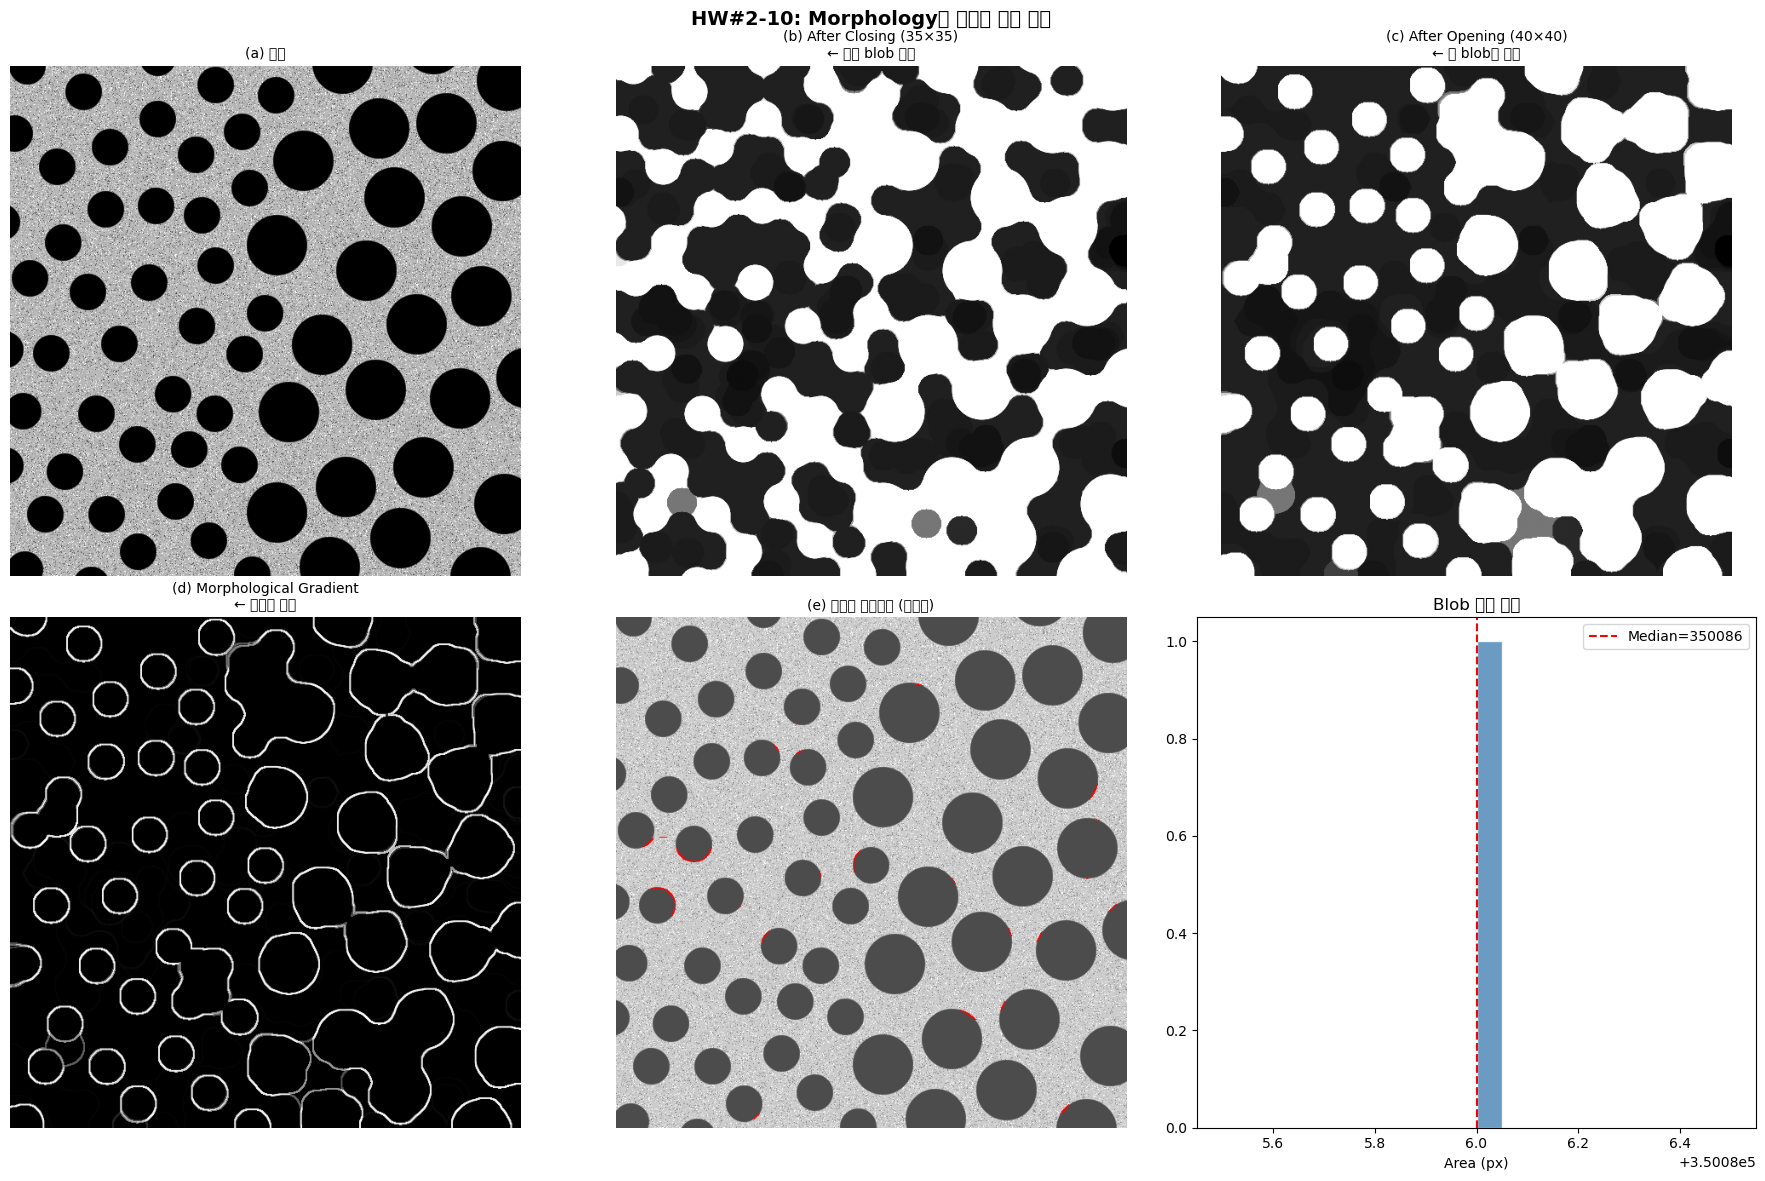

In [13]:
img10 = load_image('Fig0943(a)(dark_blobs_on_light_background).tif')

inv = cv2.bitwise_not(img10)

se_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
closed   = cv2.morphologyEx(inv, cv2.MORPH_CLOSE, se_large)

se_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
opened  = cv2.morphologyEx(closed, cv2.MORPH_OPEN, se_open)

se_grad  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
boundary = cv2.morphologyEx(opened, cv2.MORPH_GRADIENT, se_grad)

overlay = cv2.cvtColor(img10, cv2.COLOR_GRAY2BGR)
overlay[boundary > 50] = [0, 0, 255]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HW#2-10: Morphology를 이용한 영역 분할', fontsize=14, fontweight='bold')

for ax, im, title in zip(axes[0], [img10, closed, opened],
    ['(a) 원본', '(b) After Closing (35×35)\n← 작은 blob 제거',
     '(c) After Opening (40×40)\n← 큰 blob만 남음']):
    ax.imshow(im, cmap='gray'); ax.set_title(title, fontsize=10); ax.axis('off')

axes[1, 0].imshow(boundary, cmap='gray')
axes[1, 0].set_title('(d) Morphological Gradient\n← 경계선 추출', fontsize=10); axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('(e) 경계선 오버레이 (빨간선)', fontsize=10); axes[1, 1].axis('off')

ax_hist = axes[1, 2]
_, _, stats, _ = cv2.connectedComponentsWithStats(inv.astype(np.uint8))
areas = stats[1:, cv2.CC_STAT_AREA]
ax_hist.hist(areas, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax_hist.axvline(x=np.median(areas), color='red', linestyle='--',
                label=f'Median={np.median(areas):.0f}')
ax_hist.set_title('Blob 면적 분포'); ax_hist.set_xlabel('Area (px)'); ax_hist.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'hw2_10_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### HW#2-10 분석
- **(b) Closing (35×35)**: 팽창→침식. 작은 blob들이 팽창으로 채워진 후 침식 → 작은 blob 제거
- **(c) Opening (40×40)**: 침식→팽창. 큰 blob 사이 밝은 패치 제거 → 두 영역 경계 드러남
- **(d) Morphological Gradient**: 팽창-침식으로 두 영역 경계선 추출
- **Blob 면적 분포**: 소형/대형 blob 이중 피크 확인 → SE 크기 선택 근거
- **결론**: SE 크기를 두 그룹 사이 크기로 설정하는 것이 핵심